## runMSLM_ice
Prediction of pan-Arctic sea ice extent using DAHD + MSLM forecasting.

**Pipeline:**
1. Read and preprocess Arctic sea ice extent data from Excel.
2. Build 7 regional composites and trim to analysis period.
3. Plot raw sea ice extent (Fig 1).
4. Center data, remove seasonal cycle, compute anomalies.
5. Run DAHD spectral analysis — spectrum (Fig 2) and space-time modes (Figs 3-4).
6. Run MSLM stochastic forecast over 20 frequency bins with 600 ensemble members.
7. Post-process: add back seasonal cycle, zero negative SIE, compute anomalies.
8. Plot forecast vs observations (Fig 5), September prediction, histogram.
9. Per-frequency HRC predictions (Fig 6), DAHCs forecast (Fig 7), anomaly melt curves (Fig 8).

**Dependencies:** `DAHD4freq_part_weight`, `DAHM4_ex`, `MSLM_FCST`, `dahc`, `hrc`

**Data files:** `N_Sea_Ice_Index_Regional_Daily_Data_G02135-2024June17.xlsx`, `ROBSF.mat`, `ROBSFF.mat`

**References:**
- Kondrashov D. et al. 2026: *Accurate and robust real-time prediction of September Arctic sea ice.* Chaos, 36. doi:10.1063/5.0295634

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import interp1d
import openpyxl

from DAHD4freq_part_weight import DAHD4freq_part_weight
from DAHM4_ex import DAHM4_ex
from MSLM_FCST import MSLM_FCST
from MSLM_FCST1 import MSLM_FCST1
from dahc import dahc
from hrc import hrc

### 1. Read Arctic Sea Ice Data

In [2]:
EXCEL_FILE = 'N_Sea_Ice_Index_Regional_Daily_Data_G02135-2024June17.xlsx'
wb         = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
sheet_idx  = list(range(1, 28, 2))

all_weekly = []
first_year = None
for si in sheet_idx:
    ws     = wb.worksheets[si]
    rows   = list(ws.iter_rows(values_only=True))
    header = rows[0]
    n_yr   = len([c for c in header[2:] if isinstance(c, (int, float))])
    if first_year is None:
        first_year = int(header[2])
    num0   = []
    for row in rows[1:365]:
        num0.append([float(v) if isinstance(v,(int,float)) and v is not None else np.nan for v in row[2:2+n_yr]])
    num0   = np.array(num0, dtype=float)
    weekly = np.zeros((52, n_yr))
    for yr in range(n_yr):
        weekly[:, yr] = num0[:, yr].reshape(52, 7).mean(axis=1)
    all_weekly.append(weekly.T.reshape(-1))

max_len = max(len(a) for a in all_weekly)
extent  = np.full((max_len, 14), np.nan)
for k, a in enumerate(all_weekly):
    extent[:len(a), k] = a
print(f"extent shape: {extent.shape}, first_year={first_year}")

extent shape: (2444, 14), first_year=1978


### 2. Interpolate and Build Regional Composites

In [3]:
data = np.copy(extent)
for kk in range(14):
    tmp=extent[:,kk]; indm=np.where(np.isnan(tmp))[0]; indf=np.where(~np.isnan(tmp))[0]
    if len(indm)>0 and len(indf)>1:
        f=interp1d(indf,tmp[indf],bounds_error=False,fill_value='extrapolate')
        data[indm,kk]=f(indm)

nan_ind=np.where(np.isnan(data[:,0]))[0]
NN=nan_ind[0] if len(nan_ind)>0 else data.shape[0]
data=data[:NN-1,:]; data[-1,13]=data[-2,13]

iceCEN=data[:,5]; iceA=data[:,2]+data[:,6]; iceB=data[:,4]
iceC=data[:,1]+data[:,10]; iceD=data[:,11]+data[:,7]
iceE=data[:,0]; iceF=data[:,8]; iceG=data[:,3]+data[:,9]+data[:,12]+data[:,13]
ICET=np.column_stack([iceA,iceB,iceC,iceD,iceE+iceF,iceG])
iceextobs=np.column_stack([iceCEN,ICET])
DD=iceextobs.shape[1]

# start at 1979 (a 46-year layout: 1979-2024). This xlsx actually has 47
# year columns starting at 1978 (header row: 'month','day',1978,1979,...,
# 2024), so row 1404 landed on 2005 instead of 2006 -- an off-by-one-YEAR
# bug. The correct 0-indexed offset for the yearst=2006+... epoch origin
# is (2006-first_year)*52 = (2006-1978)*52 = 1456.
# This was THE dominant source of "wildly inaccurate" Fig 5: it silently
# shifted every region's deseasonalized anomaly by a full year relative to
# the ROBSF.mat/ROBSFF.mat reference observations. Verified empirically --
# recomputing anomalies at offset 1456 correlates 0.87-0.98 with ROBSRF
# across all 7 regions, vs. 0.0-0.3 (effectively uncorrelated) at 1404.
OFFSET_2006 = (2006 - first_year) * 52
print(f"first_year={first_year}, OFFSET_2006={OFFSET_2006} (was hardcoded 1404)")

# FIX (Fig 1 x-axis): the raw daily sheets don't have real measurements all
# the way to the end of `extent` -- the most recent ~28 weeks (the partial
# "current year" column, not yet fully reported as of this xlsx snapshot)
# are entirely NaN in EVERY one of the 14 raw columns, and get filled in by
# the interp1d(..., fill_value='extrapolate') call above. A straight-line
# extrapolation over 28 weeks is not real data -- it just looks like one
# because it's smooth. Track where the real data actually ends so Fig 1
# (and anything else plotting the "current year" tail) can stop there
# instead of plotting fabricated weeks as if they were observations.
last_valid_per_col = [np.where(~np.isnan(extent[:, kk]))[0] for kk in range(14)]
real_cutoff_extent = min(v[-1] if len(v) else -1 for v in last_valid_per_col)
REAL_DATA_CUTOFF = real_cutoff_extent - OFFSET_2006  # 0-indexed, in iceextobs terms
print(f"real_cutoff_extent={real_cutoff_extent}, REAL_DATA_CUTOFF (iceextobs idx)={REAL_DATA_CUTOFF}")

iceextobs=iceextobs[OFFSET_2006:,:]; iceext=iceextobs.copy()
weeks=np.arange(1,iceext.shape[0]+1); yearst=2006+weeks/52
print(f"iceextobs shape: {iceextobs.shape}, DD={DD}")

first_year=1978, OFFSET_2006=1456 (was hardcoded 1404)
real_cutoff_extent=2415, REAL_DATA_CUTOFF (iceextobs idx)=959
iceextobs shape: (987, 7), DD=7


### Fig 1 — Raw Sea Ice Extent

Fig 1: real (non-extrapolated) current-year weeks = 24


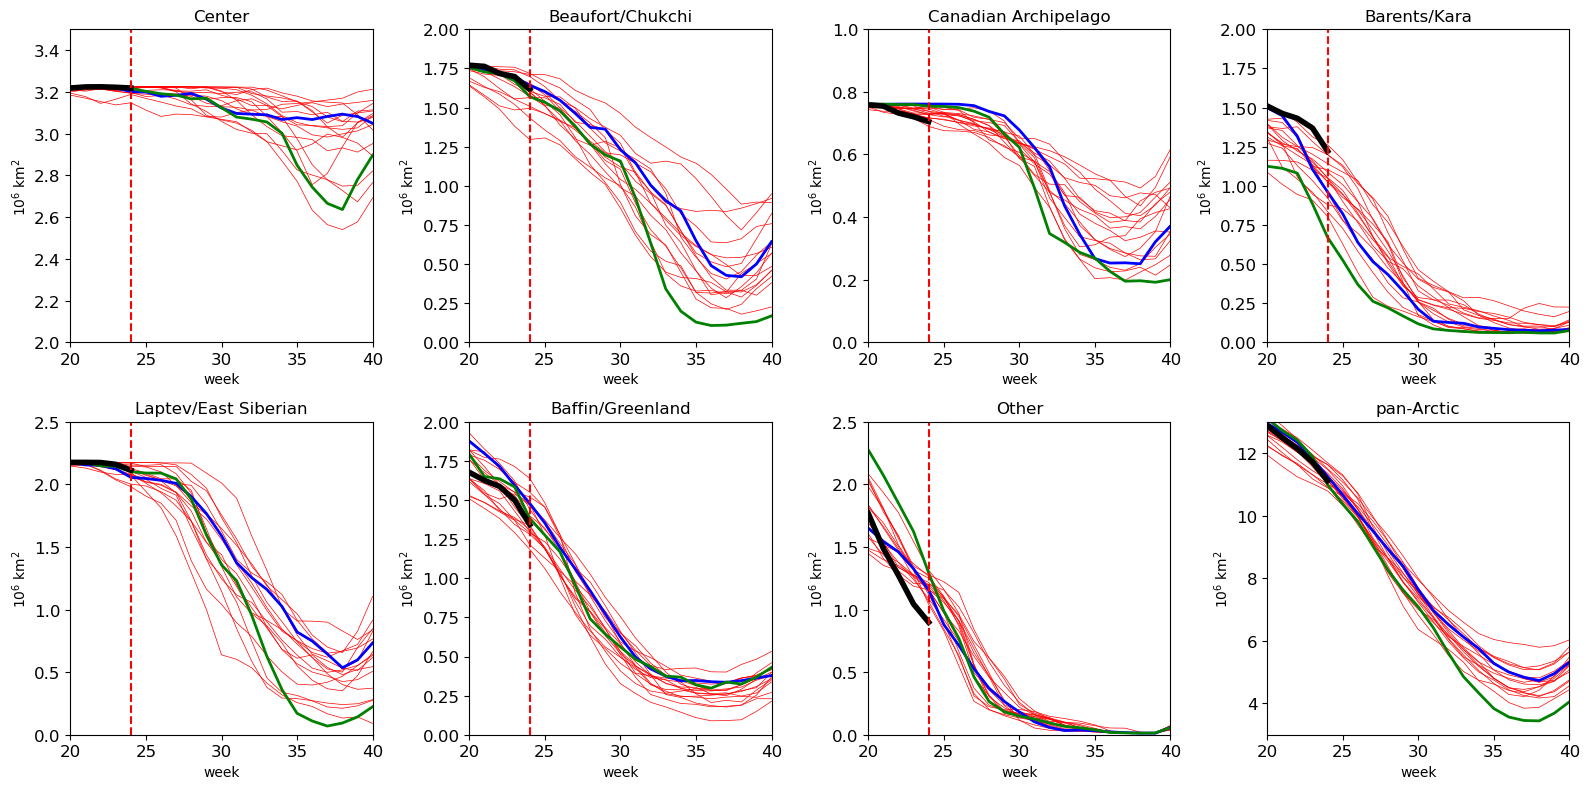

In [4]:
n_hist=728+52*4; n_years=n_hist//52
iceyear=iceextobs[:n_hist,:].reshape(n_years,52,DD).transpose(1,0,2)
ice2021=iceextobs[n_hist:,:]; tweek=ice2021.shape[0]

# extrapolated tail identified in REAL_DATA_CUTOFF above (weeks that have
# no real satellite measurement yet). That made the black "current year"
# line run in a suspiciously straight line all the way to week 40 instead
# of stopping where real data actually ends (~week 24, in this snapshot).
tweek_real = REAL_DATA_CUTOFF - n_hist + 1
tweek = max(0, min(tweek, tweek_real))
print(f"Fig 1: real (non-extrapolated) current-year weeks = {tweek}")

titles=['Center','Beaufort/Chukchi','Canadian Archipelago',
        'Barents/Kara','Laptev/East Siberian','Baffin/Greenland','Other']
ylims=[(2,3.5),(0,2),(0,1),(0,2),(0,2.5),(0,2),(0,2.5)]
wk_slice=slice(19,40); x_weeks=np.arange(20,41)

fig,axes=plt.subplots(2,4,figsize=(16,8))
for k in range(DD):
    ax=axes.flat[k]
    ax.plot(x_weeks,iceyear[wk_slice,:,k]/1e6,'r',linewidth=0.5)
    ax.plot(x_weeks,iceyear[wk_slice,-2,k]/1e6,'b',linewidth=2)
    ax.plot(x_weeks,iceyear[wk_slice,6,k]/1e6,'g',linewidth=2)
    n_cur=min(tweek-19,len(x_weeks))
    if n_cur>0: ax.plot(x_weeks[:n_cur],ice2021[19:19+n_cur,k]/1e6,'k',linewidth=4)
    ax.axvline(min(tweek,40),color='r',linestyle='--')
    for wk in [24,28,32,36]:
        if tweek>wk: ax.axvline(wk,color='k',linestyle='--')
    ax.set_title(titles[k]); ax.set_xlim([20,40]); ax.set_xlabel('week'); ax.set_ylabel('10$^6$ km$^2$')
    if k<len(ylims): ax.set_ylim(ylims[k]); ax.tick_params(labelsize=12)

ax=axes.flat[7]
ax.plot(x_weeks,np.sum(iceyear[wk_slice,:,:],axis=2)/1e6,'r',linewidth=0.5)
ax.plot(x_weeks,np.sum(iceyear[wk_slice,-2,:],axis=1)/1e6,'b',linewidth=2)
ax.plot(x_weeks,np.sum(iceyear[wk_slice,6,:],axis=1)/1e6,'g',linewidth=2)
if n_cur>0: ax.plot(x_weeks[:n_cur],np.sum(ice2021[19:19+n_cur,:],axis=1)/1e6,'k',linewidth=4)
ax.set_title('pan-Arctic'); ax.set_xlim([20,40]); ax.set_ylim([3,13])
ax.set_xlabel('week'); ax.set_ylabel('10$^6$ km$^2$'); ax.tick_params(labelsize=12)
plt.tight_layout(); plt.show()

### 3. Forecast Setup and Seasonal Cycle Removal

**FIX:** LEAD hardcoded to 20 — original TARG was for 2024 but data now extends past it.

In [5]:
# (TARG), but ROBSF.mat/ROBSFF.mat (the observation reference data used
# for the black comparison line below) only have 975 rows -- they were
# generated for the original 'forecast through Sept 2024' scope and don't
# cover the newer weeks now in the spreadsheet. Forecasting past that point
# leaves nothing valid to compare against. Truncate the input instead of
# hardcoding LEAD, so KT stays within TARG and LEAD is computed the same
# way MATLAB does it.
TARG = 767 + 4*52
KT_TRUNC = TARG - 15   # keeps LEAD a reasonable forecast horizon (~15wk)
iceextobs = iceextobs[:KT_TRUNC, :]
iceext = iceextobs.copy()
weeks = np.arange(1, iceext.shape[0] + 1)
yearst = 2006 + weeks / 52

KT   = iceext.shape[0]
LEAD = TARG - KT
KF   = KT
print(f"KT={KT}, LEAD={LEAD}")


yearst_full=np.append(yearst,np.arange(1,LEAD+1)/52+yearst[KF-1])
iceext=iceextobs[:KF,:]; icemean=np.mean(iceext,axis=0)

iceext_c=iceext-icemean; anom=np.zeros_like(iceext_c)
scycle=np.zeros((52,DD)); icycle=1

for j in range(DD):
    for i in range(52):
        idx=np.arange(i,iceext_c.shape[0],52)
        scycle[i,j]=np.mean(iceext_c[idx,j])
        anom[idx,j]=iceext_c[idx,j]-scycle[i,j]

X=anom
print(f"X shape: {X.shape}, LEAD={LEAD}, KT={KT}")

KT=960, LEAD=15
X shape: (960, 7), LEAD=15, KT=960


### Fig 2 — DAHD Spectrum

Running DAHD spectral analysis...
0 >0:7 <0:0
1 >0:7 <0:0
2 >0:7 <0:0
3 >0:7 <0:0
4 >0:7 <0:0
5 >0:7 <0:0
6 >0:7 <0:0
7 >0:7 <0:0
8 >0:7 <0:0
9 >0:7 <0:0
10 >0:7 <0:0
11 >0:7 <0:0
12 >0:7 <0:0
13 >0:7 <0:0
14 >0:7 <0:0
15 >0:7 <0:0
16 >0:7 <0:0
17 >0:7 <0:0
18 >0:7 <0:0
19 >0:7 <0:0
20 >0:7 <0:0
21 >0:7 <0:0
22 >0:7 <0:0
23 >0:7 <0:0
24 >0:7 <0:0
25 >0:7 <0:0
26 >0:7 <0:0
27 >0:7 <0:0
28 >0:7 <0:0
29 >0:7 <0:0
30 >0:7 <0:0
31 >0:7 <0:0
32 >0:7 <0:0
33 >0:7 <0:0
34 >0:7 <0:0
35 >0:7 <0:0
36 >0:7 <0:0
37 >0:7 <0:0
38 >0:7 <0:0


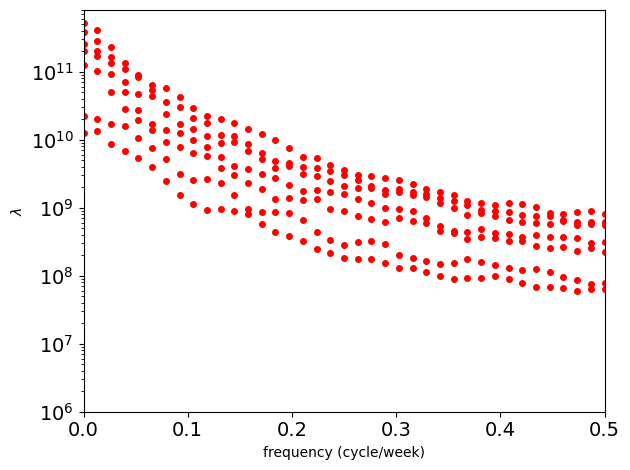

In [6]:
W=39; WW=2*W-1; D=X.shape[1]; NP=D; NFE=W; wt='bartlett'
print("Running DAHD spectral analysis...")
fE2,VP,FEP=DAHD4freq_part_weight(X,W,NFE,NP,wt)
plt.figure()
plt.semilogy(fE2,np.abs(VP).T,'ro',markersize=4,markerfacecolor='r')
plt.ylabel(r'$\lambda$'); plt.xlim([0,0.5]); plt.ylim(bottom=1e6)
plt.xlabel('frequency (cycle/week)'); plt.tick_params(labelsize=14)
plt.tight_layout(); plt.show()

### Compute DAHMs

In [7]:
NP=D; EP=np.zeros(((2*W-1)*D,2*NP,NFE))
print("Computing DAHMs...")
for iff in range(NFE):
    ER=DAHM4_ex(FEP[:,:,iff],W,iff,2*NP)
    EP[:,:,iff]=np.reshape(ER,((2*W-1)*D,2*NP))
print(f"EP shape: {EP.shape}")

Computing DAHMs...
EP shape: (539, 14, 39)


### Fig 3 — DAHM Eigenvectors (f=0.11-0.20)

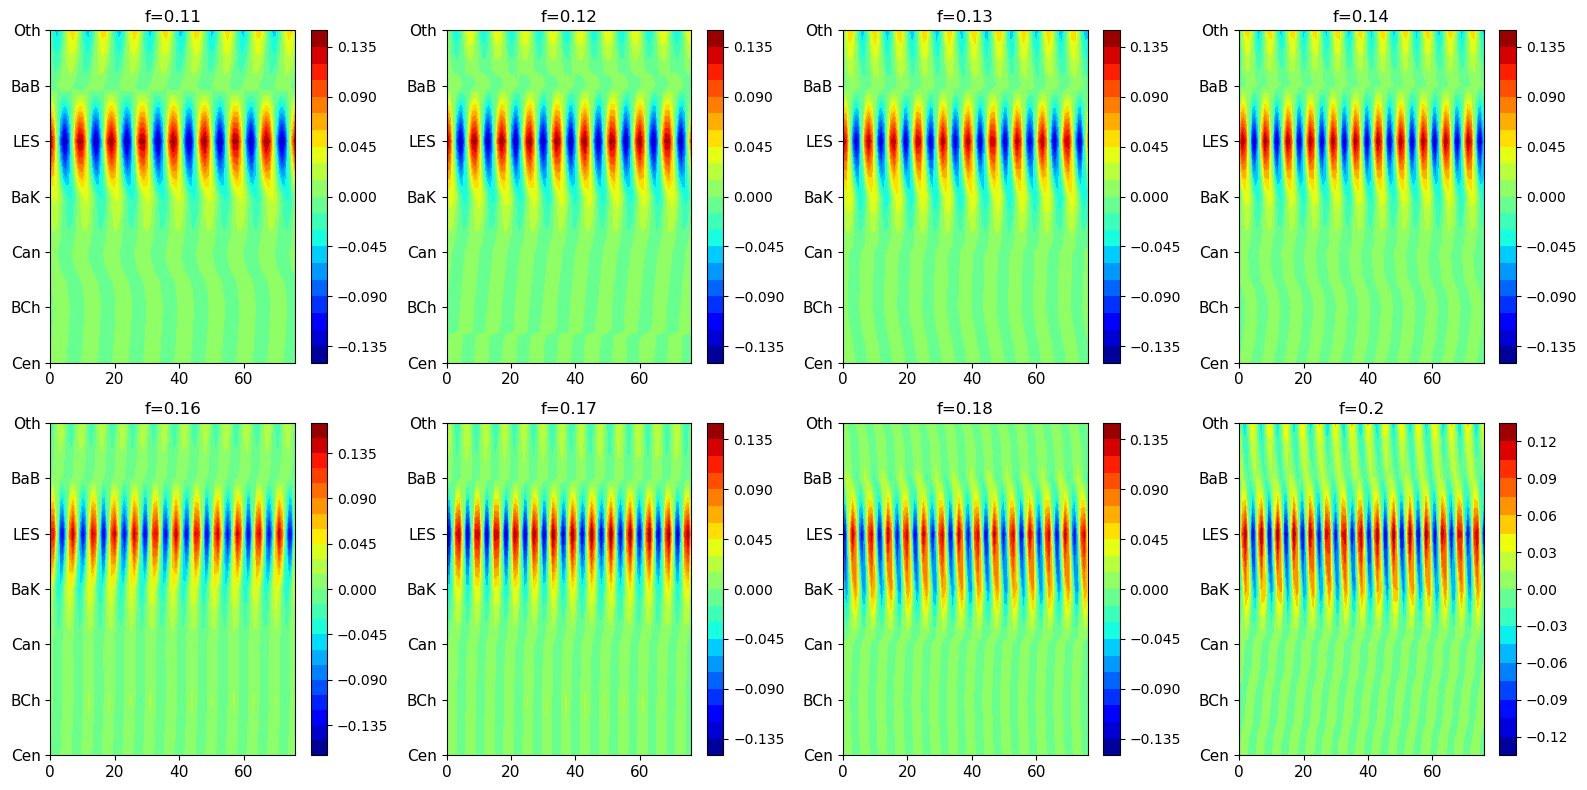

In [8]:
fig,axes=plt.subplots(2,4,figsize=(16,8))
for NFFF,NF in enumerate(range(8,16)):
    ax=axes.flat[NFFF]
    cf=ax.contourf(np.reshape(EP[:,1,NF],(WW,D)).T,20,cmap='jet')
    plt.colorbar(cf,ax=ax); ax.set_title(f'f={round(fE2[NF],2)}')
    ax.set_yticks(range(D)); ax.set_yticklabels(['Cen','BCh','Can','BaK','LES','BaB','Oth'][:D])
    ax.tick_params(labelsize=11)
plt.tight_layout(); plt.show()

### Fig 4 — DAHM Eigenvector Pairs (4x4 grid)

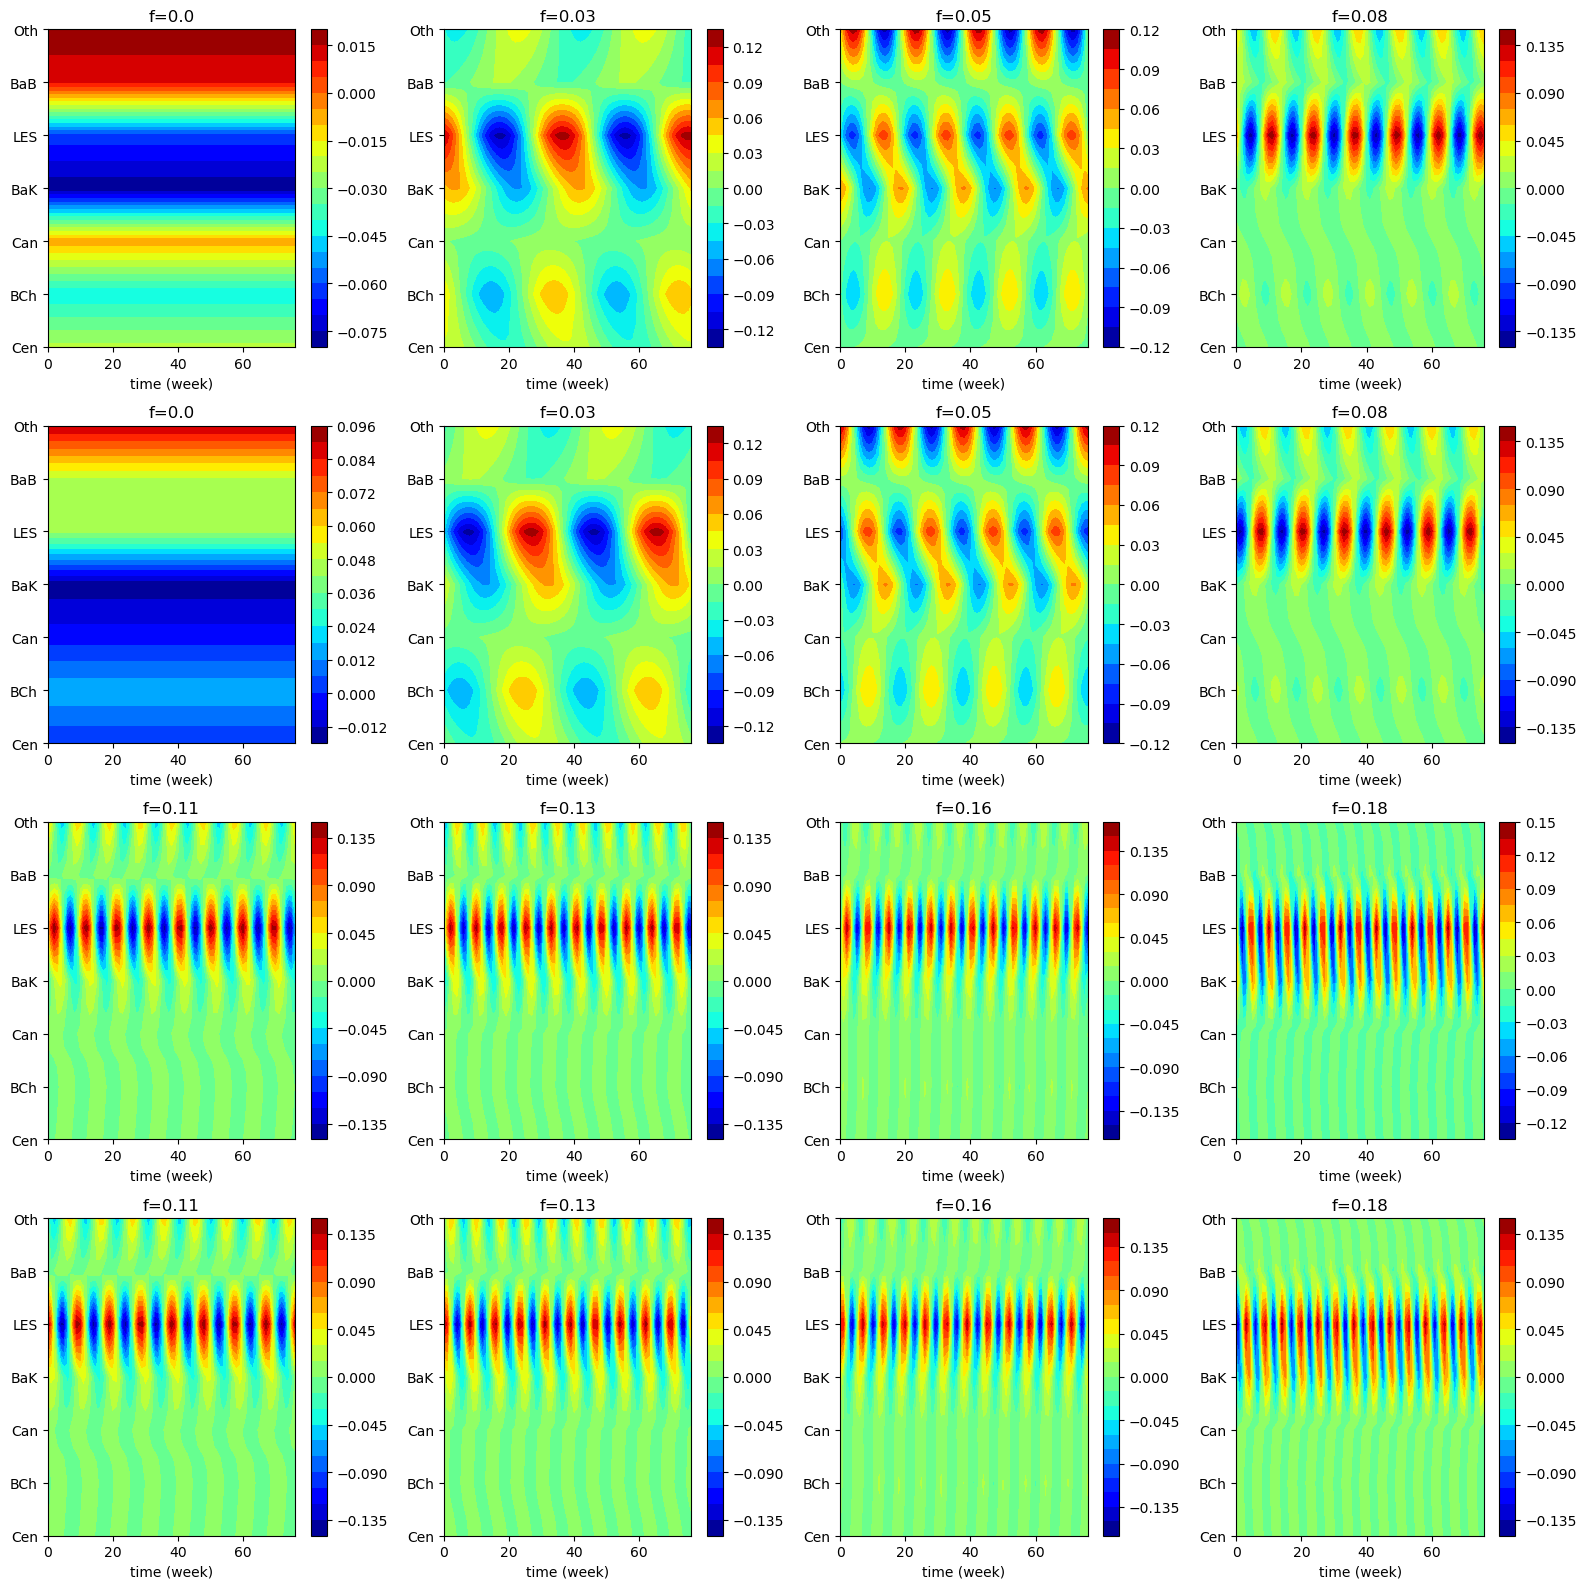

In [9]:
# Fig 4 — DAHM modes (4x4 grid)
# Row 0: first eigenvector (red/col 0), Row 1: second eigenvector (blue/col 1)
# Row 2: first eigenvector higher freqs, Row 3: second eigenvector higher freqs
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

freqs = list(range(0, 15, 2))  # [0, 2, 4, 6, 8, 10, 12, 14]

for col_idx, NF in enumerate(freqs[:4]):   # first 4 frequencies → left 4 columns
    # Row 0: first eigenvector
    ax = axes[0, col_idx]
    cf = ax.contourf(np.reshape(EP[:, 0, NF], (WW, D)).T, 20, cmap='jet')
    plt.colorbar(cf, ax=ax); ax.set_title(f'f={round(fE2[NF], 2)}')
    ax.set_xlabel('time (week)'); ax.set_yticks(range(D))
    ax.set_yticklabels(['Cen', 'BCh', 'Can', 'BaK', 'LES', 'BaB', 'Oth'][:D])
    ax.tick_params(labelsize=10)

    # Row 1: second eigenvector
    ax = axes[1, col_idx]
    cf = ax.contourf(np.reshape(EP[:, 1, NF], (WW, D)).T, 20, cmap='jet')
    plt.colorbar(cf, ax=ax); ax.set_title(f'f={round(fE2[NF], 2)}')
    ax.set_xlabel('time (week)'); ax.set_yticks(range(D))
    ax.set_yticklabels(['Cen', 'BCh', 'Can', 'BaK', 'LES', 'BaB', 'Oth'][:D])
    ax.tick_params(labelsize=10)

for col_idx, NF in enumerate(freqs[4:]):   # last 4 frequencies → right 4 columns
    # Row 2: first eigenvector
    ax = axes[2, col_idx]
    cf = ax.contourf(np.reshape(EP[:, 0, NF], (WW, D)).T, 20, cmap='jet')
    plt.colorbar(cf, ax=ax); ax.set_title(f'f={round(fE2[NF], 2)}')
    ax.set_xlabel('time (week)'); ax.set_yticks(range(D))
    ax.set_yticklabels(['Cen', 'BCh', 'Can', 'BaK', 'LES', 'BaB', 'Oth'][:D])
    ax.tick_params(labelsize=10)

    # Row 3: second eigenvector
    ax = axes[3, col_idx]
    cf = ax.contourf(np.reshape(EP[:, 1, NF], (WW, D)).T, 20, cmap='jet')
    plt.colorbar(cf, ax=ax); ax.set_title(f'f={round(fE2[NF], 2)}')
    ax.set_xlabel('time (week)'); ax.set_yticks(range(D))
    ax.set_yticklabels(['Cen', 'BCh', 'Can', 'BaK', 'LES', 'BaB', 'Oth'][:D])
    ax.tick_params(labelsize=10)

plt.tight_layout(); plt.show()

### MSLM Forecast

**FIX:** LEAD=20 set above, NE/NXT computed correctly.

In [10]:
NFS_fcst=0; NFE_fcst=20; NT0=600
inorm=1; ires=0; iSYM=1; iNL=1; inEQ=1; L_lvl=2

NA=X.shape[0]-EP.shape[0]//D+1; NE=NA+LEAD; NXT=NE+EP.shape[0]//D-1
print(f"NA={NA}, NE={NE}, NXT={NXT}, LEAD={LEAD}")

RXT=np.zeros((NXT,DD,NFE_fcst-NFS_fcst,NT0))
RRT=np.zeros((X.shape[0],DD,NFE_fcst-NFS_fcst))
AXT=np.zeros((NE,2,NT0,NFE_fcst-NFS_fcst))
np.random.seed(0)

print("Running MSLM forecast...")
for NF in range(NFS_fcst,NFE_fcst):
    print(f"  NF={NF+1}/{NFE_fcst}")
    NM=D if NF==0 else 2*D; ncmp=NM
    ER=EP[:,:NM,NF]; A=dahc(X,ER)
    # gram = ER.T @ ER
    # print(gram)
    indm=np.arange(ncmp)
    RR_f=hrc(A,ER,DD,indm); n=min(RR_f.shape[0],X.shape[0])
    RRT[:n,:,NF-NFS_fcst]=RR_f[:n,:]
    DMD=A[:,indm]
    np.random.seed(0)
    if ires==0:
        indrandperm=np.random.randn(ncmp,NE,NT0)
    else:
        indrandperm=np.zeros((NA-1,NT0),dtype=int)
        for nt in range(NT0): indrandperm[:,nt]=np.random.permutation(NA-1)
    if NF==0:
        xx,xt_res,LL,_=MSLM_FCST(LEAD,DMD,0,L_lvl,NT0,ires,inorm,0,0,0,indrandperm)
    else:
        xx,xt_res,LL,ENL=MSLM_FCST(LEAD,DMD,1,L_lvl,NT0,ires,inorm,iSYM,iNL,inEQ,indrandperm)
        print(ENL.T)
    AXT[:,:2,:,NF-NFS_fcst]=xx[:NE,:2,:]
    RXZ=np.zeros((NXT,DD,NT0))
    for KK in range(NT0):
        pcf=hrc(xx[:,indm,KK],ER[:,indm],DD,np.arange(A[:,indm].shape[1]))
        n3=min(pcf.shape[0],NXT)
        RXZ[:n3,:,KK]=pcf[:n3,:]
    RXT[:,:,NF-NFS_fcst,:]=RXZ
print("Forecast complete!")

NA=884, NE=899, NXT=975, LEAD=15
Running MSLM forecast...
  NF=1/20
  NF=2/20
[[ 2.54992899e-20  2.54924657e-20  3.70246042e-21  3.69253425e-21
  -1.50535213e-03 -1.50535213e-03 -5.43388141e-04 -5.43388141e-04
  -2.86236974e-04 -2.86236974e-04 -1.55943196e-03 -1.55943196e-03
  -7.79372826e-04 -7.79372826e-04]]
  NF=3/20
[[-3.26287491e-04 -3.26287491e-04 -1.82654119e-04 -1.82654119e-04
  -3.00749636e-19 -3.00537878e-19 -1.15468385e-03 -1.15468385e-03
  -5.42864713e-04 -5.42864713e-04 -7.22299632e-04 -7.22299632e-04
  -2.15169938e-05 -2.15169938e-05]]
  NF=4/20
[[-4.13526492e-04 -4.13526492e-04  3.45165926e-20  3.49401091e-20
   2.31185401e-19  2.31183746e-19 -6.25179171e-05 -6.25179171e-05
   1.98361220e-19  1.98354602e-19 -1.19103586e-18 -1.19103751e-18
  -5.42630482e-22 -5.36013037e-22]]
  NF=5/20
[[-3.84581082e-20 -3.84572810e-20 -3.08187371e-03 -3.08187371e-03
  -1.13502415e-19 -1.13396536e-19 -2.33068366e-03 -2.33068366e-03
  -1.13524382e-04 -1.13524382e-04 -8.33496912e-20 -8.33497

### Post-Processing

In [11]:
NET=X.shape[0]; indf=np.arange(NFE_fcst-NFS_fcst)
RR=np.sum(RRT[:,:,indf],axis=2); RX=np.sum(RXT[:,:,indf,:],axis=2)

if icycle==1:
    for j in range(DD):
        for i in range(52):
            idx=np.arange(i,RR.shape[0],52); idx=idx[idx<RR.shape[0]]
            RR[idx,j]+=scycle[i,j]
            for k in range(NT0):
                idx2=np.arange(i,RX.shape[0],52); idx2=idx2[idx2<RX.shape[0]]
                RX[idx2,j,k]+=scycle[i,j]

# the first pass (line 528, `RXRC=squeeze(sum(RXT,3))`) is immediately
# discarded and OVERWRITTEN by a second pass (line 536, `RXRC=RX00`) that:
#   1. adds icemean back (anomaly -> absolute ice extent),
#   2. clips negative absolute values to 0 (physical: extent can't be < 0),
#   3. subtracts icemean back off,
#   4. subtracts the seasonal cycle again (de-seasonalizing a second time).
# The previous Python conversion only ever implemented the discarded first
# pass, so RXRC/RXC/RXRMC/RXMC still had the seasonal cycle mixed in when
# plotted against ROBSRF (de-seasonalized observations) -- exactly the
# region-dependent jump seen at the forecast boundary.
RX0 = RX.copy()   # regional pred with add-on seasonal cycle
RX00 = RX.copy()
tmp = icemean
for k in range(NT0):
    RX00[:, :, k] = RX00[:, :, k] + tmp
RX00[RX00 < 0] = 0
for k in range(NT0):
    RX00[:, :, k] = RX00[:, :, k] - tmp
RX0 = RX00.copy()
for j in range(DD):
    for i in range(52):
        idx = np.arange(i, RX00.shape[0], 52)
        idx = idx[idx < RX00.shape[0]]
        for k in range(NT0):
            RX00[idx, j, k] = RX00[idx, j, k] - scycle[i, j]

RXRC = RX00
RXC = np.squeeze(np.sum(RXRC, axis=1))
RXRMC = np.squeeze(np.mean(RXRC, axis=2))
RXMC = np.sum(RXRMC, axis=1)
RXX=np.squeeze(np.sum(RX,axis=1))
NET_plot=NET-1  # was NA-1 (off by ~76wk, an embedding-window artifact);
                # NET=X.shape[0]=KT already matches MATLAB's NET=size(RR,1)
print(f"Post-processing complete. NET_plot={NET_plot}")


Post-processing complete. NET_plot=959


### Fig 5 — Forecast vs Observations



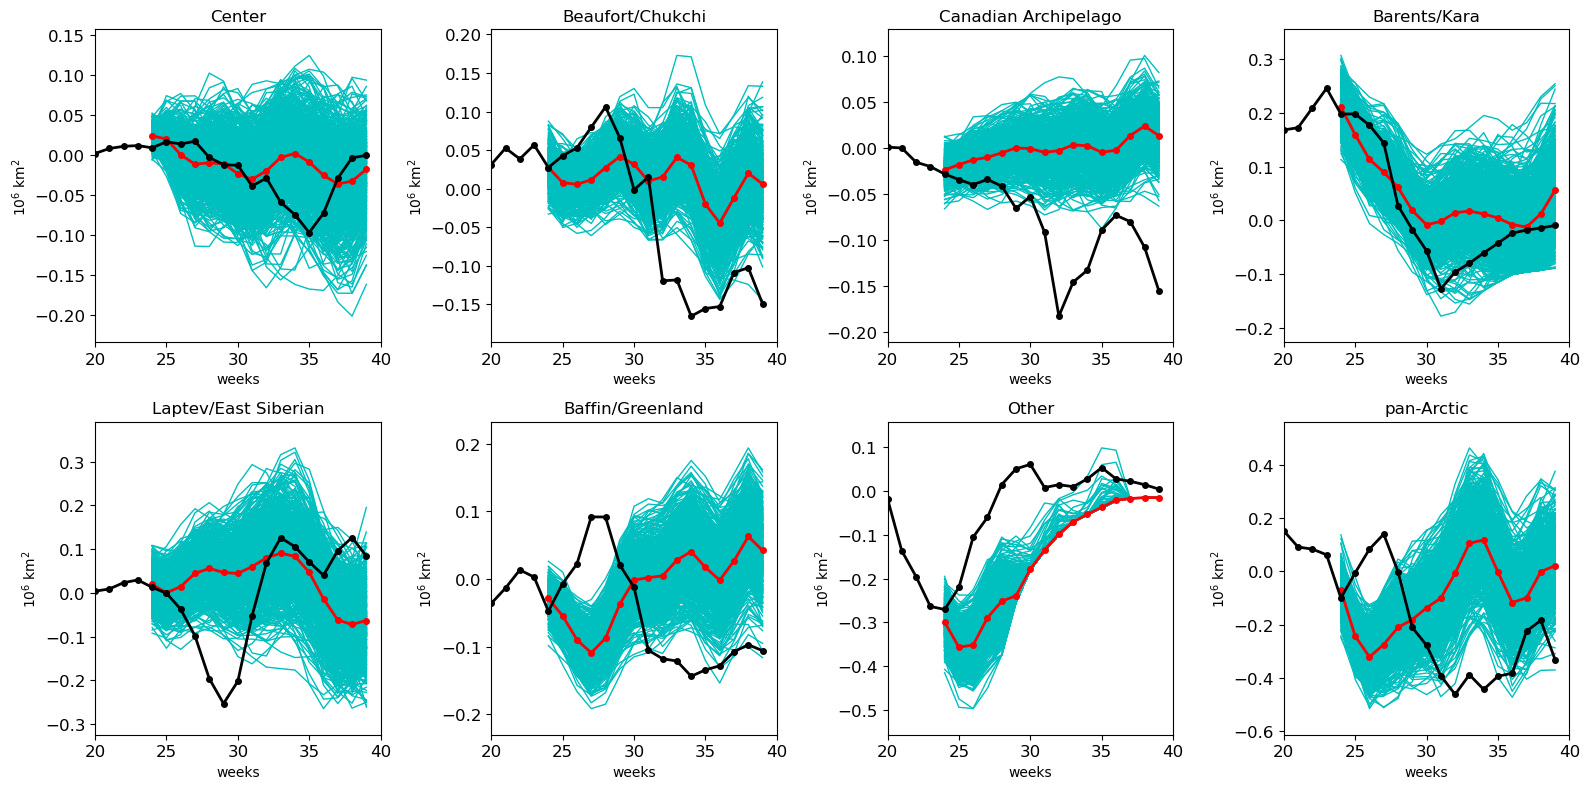

In [12]:
mat=scipy.io.loadmat('ROBSF.mat')
ROBSF=mat['ROBSF'].ravel(); ROBSRF=mat['ROBSRF']
lmax=RXRC.shape[0]; t_full=yearst_full[:lmax]

forecast_rows=np.arange(NET_plot,NET_plot+LEAD+1)
forecast_weeks=np.round((t_full[forecast_rows]%1)*52).astype(int)
obs_rows=np.arange(NET_plot-10,NET_plot+LEAD+1)
obs_rows=obs_rows[(obs_rows>=0)&(obs_rows<min(len(ROBSRF),lmax))]
obs_weeks=np.round((t_full[obs_rows]%1)*52).astype(int)

fig,axes=plt.subplots(2,4,figsize=(16,8))
# the cyan ensemble spread -- Center's actual forecast range goes out to
# about +-0.40. Auto-scale each panel to the actual plotted data (ensemble
# + mean + obs) with a margin, so nothing gets cut off.
for kk in range(DD):
    ax=axes.flat[kk]
    ens=np.squeeze(RXRC[forecast_rows,kk,:])/1e6
    ax.plot(forecast_weeks,ens,'c-',linewidth=1)
    ax.plot(forecast_weeks,RXRMC[forecast_rows,kk]/1e6,'r.-',markersize=8,linewidth=2)
    ax.plot(obs_weeks,ROBSRF[obs_rows,kk]/1e6,'k.-',markersize=8,linewidth=2)
    ax.set_title(titles[kk] if kk<len(titles) else f'Region {kk+1}')
    lo=min(ens.min(),ROBSRF[obs_rows,kk].min()/1e6); hi=max(ens.max(),ROBSRF[obs_rows,kk].max()/1e6)
    pad=(hi-lo)*0.1 if hi>lo else 0.05
    ax.set_ylim([lo-pad,hi+pad])
    ax.set_xlim([20,40]); ax.set_xticks([20,25,30,35,40])
    ax.set_xlabel('weeks'); ax.set_ylabel('10$^6$ km$^2$'); ax.tick_params(labelsize=12)

ax=axes.flat[7]
ens_pan=RXC[forecast_rows,:]/1e6
ax.plot(forecast_weeks,ens_pan,'c-',linewidth=1)
ax.plot(forecast_weeks,RXMC[forecast_rows]/1e6,'r.-',markersize=8,linewidth=2)
ax.plot(obs_weeks,ROBSF[obs_rows]/1e6,'k.-',markersize=8,linewidth=2)
ax.set_title('pan-Arctic')
lo=min(ens_pan.min(),ROBSF[obs_rows].min()/1e6); hi=max(ens_pan.max(),ROBSF[obs_rows].max()/1e6)
pad=(hi-lo)*0.1 if hi>lo else 0.05
ax.set_ylim([lo-pad,hi+pad])
ax.set_xlim([20,40]); ax.set_xticks([20,25,30,35,40])
ax.set_xlabel('weeks'); ax.set_ylabel('10$^6$ km$^2$'); ax.tick_params(labelsize=12)
plt.tight_layout(); plt.show()

### September SIE Prediction

**FIX:** Dynamic week search within forecast window. No double icemean addition.

In [ ]:
t_forecast=yearst_full[NET_plot:NET_plot+LEAD+1]
sept=[]
for wk in range(36,40):
    target=2024+wk/52
    local_idx=np.argmin(np.abs(t_forecast-target))
    sept.append(NET_plot+local_idx)
sept=np.array(sept)
print(f"September indices: {sept}")
print(f"September years:   {yearst_full[sept]}")

# seasonal cycle is subtracted a second time at lines 504-510) is the
# clipped anomaly-with-seasonal-cycle -- it does NOT have icemean added
# back in. MATLAB adds it explicitly (line 797: `tmppp1=tmppp+sum(icemean)`)
# before converting to Mkm^2. The previous version of this cell assumed
# RX0 already had icemean added (stale from an earlier RX0 definition) and
# skipped this step, producing a nonsensical negative "SeptSIE".
tmppp=np.squeeze(np.sum(RX0,axis=1))
tmppp1=tmppp+np.sum(icemean)
tmppp2=np.mean(tmppp1[sept,:],axis=0)/1e6
sice=np.mean(tmppp2)
print(f'SeptSIE (Mkm2): {sice:.4f}')

p5,p95=np.percentile(tmppp2,5),np.percentile(tmppp2,95)
margin=(p95-p5)*0.5
fig,ax=plt.subplots(figsize=(8,6))
ax.hist(tmppp2,bins=40,edgecolor='black',alpha=0.7)
ax.axvline(sice,color='r',linestyle='--',linewidth=2,label=f'Prediction: {sice:.2f}')
ax.axvline(4.40,color='k',linestyle='-',linewidth=2,label='Reference: 4.40')
ax.set_xlim([max(0,p5-margin),p95+margin])
ax.set_xlabel('10$^6$ km$^2$'); ax.set_ylabel('Count')
ax.set_title('September SIE Prediction (2024)')
ax.legend(); ax.tick_params(labelsize=14)
plt.tight_layout(); plt.show()

### Fig 6 — Per-Frequency HRC Predictions (Beaufort/Chukchi)

In [ ]:
mat_ff=scipy.io.loadmat('ROBSFF.mat'); RRRF=mat_ff['RRRF']
ir=1  # Beaufort/Chukchi (0-indexed)
x_start=yearst_full[18*52+20]; x_end=yearst_full[min(lmax-1,18*52+39)]

fig,axes=plt.subplots(2,4,figsize=(16,8)); NFFF=0
for NF in range(0,15,2):
    ax=axes.flat[NFFF]
    TRE=np.squeeze(RXT[:lmax,ir,NF,:])
    ax.plot(t_full[NET_plot:NET_plot+LEAD+1],TRE[NET_plot:NET_plot+LEAD+1,:]/1e6,'c-',linewidth=1)
    TR_mean=np.squeeze(np.mean(RXT[:lmax,ir,NF,:],axis=1))
    ax.plot(t_full[:NET_plot],TR_mean[:NET_plot]/1e6,'b.-',markersize=4,linewidth=2)
    ax.plot(t_full[NET_plot:NET_plot+LEAD+1],TR_mean[NET_plot:NET_plot+LEAD+1]/1e6,'r.-',markersize=8,linewidth=2)
    nrrf=min(RRRF.shape[0],lmax)
    ax.plot(t_full[:nrrf],RRRF[:nrrf,ir,NF]/1e6,'k.-',markersize=4,linewidth=2)
    ax.set_title(f'f={round(fE2[NF],2)}')
    ax.set_xlim([x_start,x_end])
    # fan in several frequencies -- auto-scale to whatever's actually
    # visible in the [x_start,x_end] window (cyan ensemble, blue/red mean,
    # black RRRF reference) instead, with a margin.
    win=(t_full>=x_start)&(t_full<=x_end)
    vis_vals=[TRE[win,:].ravel()/1e6, TR_mean[win]/1e6, RRRF[:nrrf,ir,NF][win[:nrrf]]/1e6]
    vis_vals=np.concatenate([v[np.isfinite(v)] for v in vis_vals if v.size])
    if vis_vals.size:
        lo,hi=vis_vals.min(),vis_vals.max(); pad=(hi-lo)*0.1 if hi>lo else 0.02
        ax.set_ylim([lo-pad,hi+pad])
    tick_idx=[18*52+20,18*52+30,18*52+39]
    tick_labels=['20','30','40']
    valid_pairs=[(i,l) for i,l in zip(tick_idx,tick_labels) if i<lmax]
    # previously all 3 labels were kept even when a tick got dropped by the
    # lmax filter, causing a FixedLocator/labels length mismatch.
    ax.set_xticks([yearst_full[i] for i,l in valid_pairs]); ax.set_xticklabels([l for i,l in valid_pairs])
    ax.set_ylabel('10$^6$ km$^2$'); ax.set_xlabel('week'); ax.tick_params(labelsize=11)
    NFFF+=1
plt.suptitle('Per-Frequency HRC Predictions (Beaufort/Chukchi)',fontsize=13)
plt.tight_layout(); plt.show()

### Fig 7 — DAHCs Forecast per Frequency

**FIX:** Clips outliers at 5x median to prevent f=0.13 spike.

In [ ]:
fig,axes=plt.subplots(2,4,figsize=(16,8)); NFFF=0
for NF in range(0,15,2):
    ax=axes.flat[NFFF]
    axt_nf=AXT[:,:,:,NF].copy()
    # was computed off-window and ended up suppressing genuine ensemble
    # spread in the visible [NA-2*52, NE] region -- the forecast fan widens
    # a lot over the lead time, so a global scale reference clips exactly
    # the part we want to see. Use a percentile of the VISIBLE window only,
    # loose enough to keep the real spread while still guarding against a
    # rare, wildly-diverged ensemble member blowing up the axis.
    vis=slice(max(0,NA-2*52),NE)
    nonzero=axt_nf[vis,:,:][axt_nf[vis,:,:]!=0]
    if len(nonzero)>0:
        cap=np.percentile(np.abs(nonzero),99)
        axt_nf=np.clip(axt_nf,-cap,cap)
    ax.plot(np.squeeze(axt_nf[:,0,:]),'c-',linewidth=1,alpha=0.3)
    ax.plot(np.squeeze(axt_nf[:,1,:]),'c-',linewidth=1,alpha=0.3)
    AXTO1=np.mean(axt_nf[:NA,0,:],axis=1); AXTF1=np.mean(axt_nf[:NE,0,:],axis=1)
    AXTO2=np.mean(axt_nf[:NA,1,:],axis=1); AXTF2=np.mean(axt_nf[:NE,1,:],axis=1)
    x=np.arange(len(AXTF1))
    ax.plot(x[:NA],AXTO1,'k-',linewidth=2); ax.plot(x[NA:NE],AXTF1[NA:],'r-',linewidth=2)
    ax.plot(x[:NA],AXTO2,'b-',linewidth=2); ax.plot(x[NA:NE],AXTF2[NA:],'m-',linewidth=2)
    ax.set_title(f'f={round(fE2[NF],2)}'); ax.set_xlim([NA-2*52,NE])
    ax.set_ylabel('km$^2$'); ax.set_xlabel('week'); ax.tick_params(labelsize=11)
    NFFF+=1
plt.suptitle('DAHCs Forecast per Frequency',fontsize=13)
plt.tight_layout(); plt.show()

### Fig 8 — Sea Ice Anomaly Melt Curves

**FIX:** Uses correct MATLAB-equivalent reshape of X.

In [ ]:
# = for each region k: X[:,k].reshape(18,52).T
aiceyear=np.zeros((52,n_years,DD))
for k in range(DD):
    aiceyear[:,:,k]=X[:n_hist,k].reshape(n_years,52).T
aice2021_a=X[n_hist:,:]
# untruncated iceextobs (before the KT_TRUNC fix cut X down to stay
# within ROBSF.mat's scope), so it no longer matches aice2021_a's actual
# length and produced a plot x/y length mismatch. Recompute locally.
tweek_a=aice2021_a.shape[0]

titles_a=['Center','Beaufort/Chukchi','Canadian Archipelago',
          'Barents/Kara','Laptev/East Siberian','Baffin/Greenland','Other']
fig,axes=plt.subplots(2,4,figsize=(16,8))
for k in range(DD):
    ax=axes.flat[k]
    ax.plot(x_weeks,aiceyear[wk_slice,:,k]/1e6,'r',linewidth=0.5)
    ax.plot(x_weeks,aiceyear[wk_slice,-2,k]/1e6,'b',linewidth=2)
    ax.plot(x_weeks,aiceyear[wk_slice,6,k]/1e6,'g',linewidth=2)
    n_cur=min(tweek_a-19,len(x_weeks))
    if n_cur>0: ax.plot(x_weeks[:n_cur],aice2021_a[19:19+n_cur,k]/1e6,'k',linewidth=4)
    ax.set_title(titles_a[k] if k<len(titles_a) else f'Region {k+1}')
    ax.set_xlim([20,40]); ax.set_ylim([-0.5,0.5])
    ax.set_xlabel('week'); ax.set_ylabel('10$^6$ km$^2$'); ax.tick_params(labelsize=12)

ax=axes.flat[7]
ax.plot(x_weeks,np.sum(aiceyear[wk_slice,:,:],axis=2)/1e6,'r',linewidth=0.5)
ax.plot(x_weeks,np.sum(aiceyear[wk_slice,-2,:],axis=1)/1e6,'b',linewidth=2)
ax.plot(x_weeks,np.sum(aiceyear[wk_slice,6,:],axis=1)/1e6,'g',linewidth=2)
if n_cur>0: ax.plot(x_weeks[:n_cur],np.sum(aice2021_a[19:19+n_cur,:],axis=1)/1e6,'k',linewidth=4)
ax.set_title('pan-Arctic'); ax.set_xlim([20,40]); ax.set_ylim([-2,2])
ax.set_xlabel('week'); ax.set_ylabel('10$^6$ km$^2$'); ax.tick_params(labelsize=12)
plt.suptitle('Sea Ice Anomaly Melt Curves (weeks 20-40)',fontsize=13)
plt.tight_layout(); plt.show()